Необхідні бібліотеки: matplotlib, numpy

In [ ]:
!pip install matplotlib
!pip install numpy

**Завдання 1**
1. Згенеруйте двовимірні дані (xx, yy) за допомогою numpy.random : бажано, щоб розподіл
точок був навколо деякої наперед заданої прямої (yy = kk + bb) для подальшого аналізу
результатів.
2. Напишіть функцію, яка реалізує метод найменших квадратів для пошуку оптимальних
оцінок kk� та bb�.
3. Порівняйте знайдені параметри з оцінкою np.polyfit(x,y,1) (оцінка полінома
степеню 1 методом найменших квадратів), та з початковими параметрами прямої (якщо
такі є).
4. Відобразіть на графіку знайдені оцінки лінії регресії (вашої та numpy). Якщо ви
генерували вхідні дані навколо лінії, відобразіть також її.

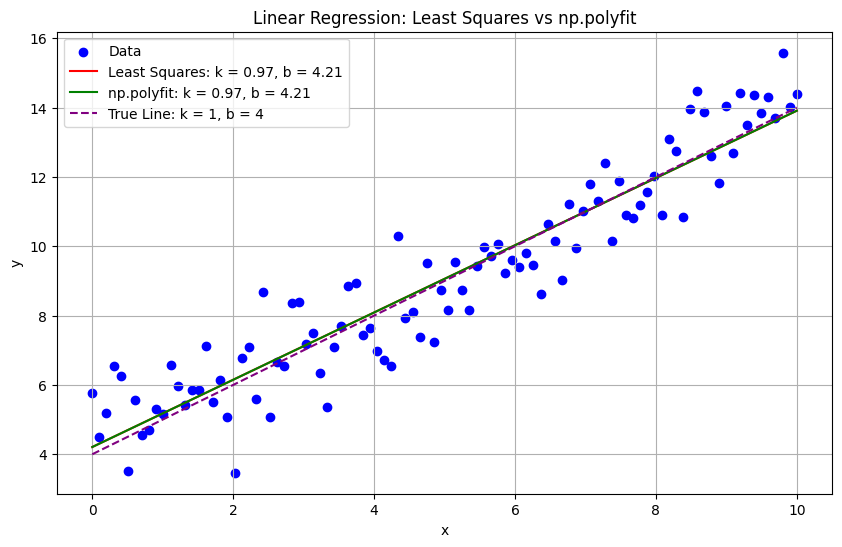

True Parameters: k = 1, b = 4
Least Squares Parameters: k = 0.97, b = 4.21
np.polyfit Parameters: k = 0.97, b = 4.21


In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n = 100 
k_true = 1 
b_true = 4 
x = np.linspace(0, 10, n)
y = k_true * x + b_true + np.random.normal(0, 1, n) 

def least_squares(x, y):
    k = np.sum((x - np.mean(x)) * (y - np.mean(y))) / np.sum((x - np.mean(x))**2)
    b = np.mean(y) - k * np.mean(x)
    return k, b

k_ls, b_ls = least_squares(x, y)

k_polyfit, b_polyfit = np.polyfit(x, y, 1)


plt.figure(figsize=(10, 6))

plt.scatter(x, y, color='blue', label='Data')

y_ls = k_ls * x + b_ls
plt.plot(x, y_ls, color='red', label=f'Least Squares: k = {k_ls:.2f}, b = {b_ls:.2f}')


y_polyfit = k_polyfit * x + b_polyfit
plt.plot(x, y_polyfit, color='green', label=f'np.polyfit: k = {k_polyfit:.2f}, b = {b_polyfit:.2f}')


y_true = k_true * x + b_true
plt.plot(x, y_true, color='purple', linestyle='--', label=f'True Line: k = {k_true}, b = {b_true}')


plt.title("Linear Regression: Least Squares vs np.polyfit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

print(f"True Parameters: k = {k_true}, b = {b_true}")
print(f"Least Squares Parameters: k = {k_ls:.2f}, b = {b_ls:.2f}")
print(f"np.polyfit Parameters: k = {k_polyfit:.2f}, b = {b_polyfit:.2f}")


**Завдання 2**
1. Напишіть функцію, яка реалізує метод градієнтного спуску для пошуку оптимальних
оцінок kk� та bb�. Визначіть оптимальні вхідні параметри: learning_rate, n_iter
2. Додайте отриману лінію регресії на загальний графік
3. Побудуйте графік похибки від кількості ітерацій, зробіть висновки
4. Порівняйте отримані результати з результатами попереднього завдання

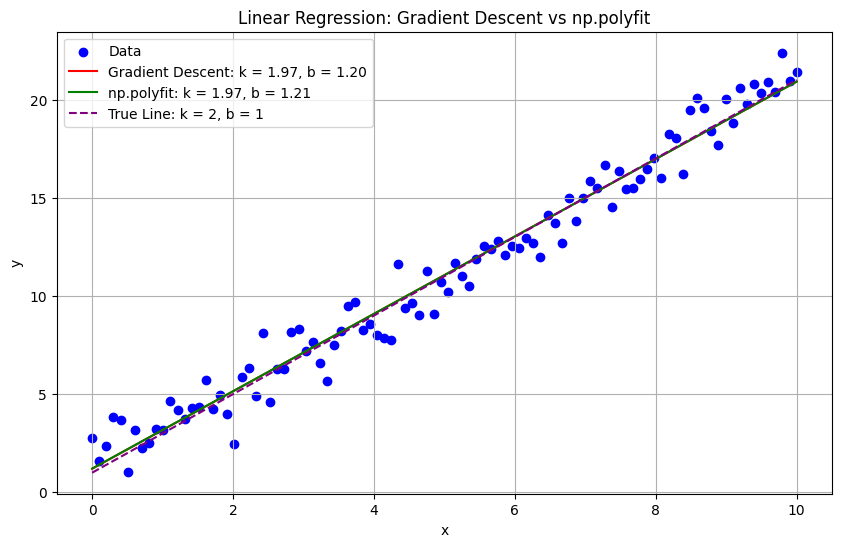

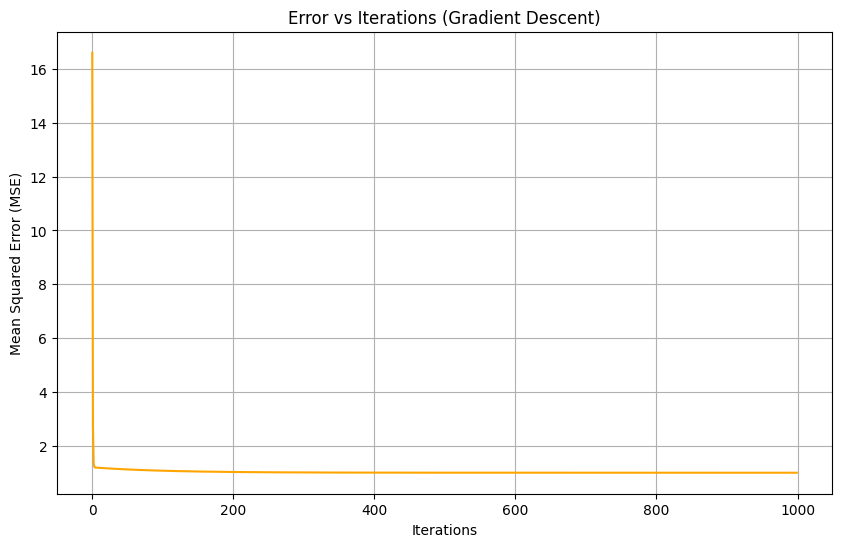

True Parameters: k = 2, b = 1
Gradient Descent Parameters: k = 1.97, b = 1.20
np.polyfit Parameters: k = 1.97, b = 1.21


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n = 100  
k_true = 2 
b_true = 1 
x = np.linspace(0, 10, n)
y = k_true * x + b_true + np.random.normal(0, 1, n)  


def mean_squared_error(k, b, x, y):
    y_mean = b + k*x
    return np.sum((y - y_mean) ** 2)/len(x)

def gradient_descent(x, y, k_init, b_init, learning_rate, n_iter):
    k = k_init
    b = b_init
    errors = []

    for _ in range(n_iter):
        y_mean = b + k*x

        grad_k = -(2 / len(x)) * np.sum(x*(y - y_mean))
        grad_b = -(2 / len(x)) * np.sum(y - y_mean)
        
        k -= learning_rate * grad_k
        b -= learning_rate * grad_b

        error = mean_squared_error(k, b, x, y)
        errors.append(error)

    return k, b, errors


learning_rate = 0.01
n_iter = 1000
k_init = 0  
b_init = 0 


k_gd, b_gd, errors = gradient_descent(x, y, k_init, b_init, learning_rate, n_iter)
y_gd = k_gd * x + b_gd


k_polyfit, b_polyfit = np.polyfit(x, y, 1)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Data')

plt.plot(x, y_gd, color='red', label=f'Gradient Descent: k = {k_gd:.2f}, b = {b_gd:.2f}')

y_polyfit = k_polyfit * x + b_polyfit
plt.plot(x, y_polyfit, color='green', label=f'np.polyfit: k = {k_polyfit:.2f}, b = {b_polyfit:.2f}')

y_true = k_true * x + b_true
plt.plot(x, y_true, color='purple', linestyle='--', label=f'True Line: k = {k_true}, b = {b_true}')

plt.title("Linear Regression: Gradient Descent vs np.polyfit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(errors, color='orange')
plt.title("Error vs Iterations (Gradient Descent)")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)
plt.show()

print(f"True Parameters: k = {k_true}, b = {b_true}")
print(f"Gradient Descent Parameters: k = {k_gd:.2f}, b = {b_gd:.2f}")
print(f"np.polyfit Parameters: k = {k_polyfit:.2f}, b = {b_polyfit:.2f}")


Графік помилок був створений за допомогою середньоквадратичної помилки(MSE).

На графіку видно, що помилка є великою з меншою кількістю ітерацію, і навпаки: помилка є малою на великій кількості ітерацій для градієнтного спуску.